# 协同过滤评估可视化

本 notebook 用于展示基于物品的协同过滤评估流程，包括数据加载、训练/测试划分、单用户推荐、整体指标评估、`top_k` 敏感性分析和可视化。

主模型位于 `src/cf_recommender.py`，评估逻辑位于 `src/evaluation.py`。

## 1. 环境与数据加载

先导入项目模块，并加载评分矩阵。这里会顺手检查 `scikit-learn` 版本，确保当前环境可正常使用。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from IPython.display import display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cf_recommender import (
    attach_movie_titles,
    compute_item_similarity,
    load_movie_title_map,
    predict_ratings_item_based,
    recommend_items_item_based,
)
from src.evaluation import (
    SKLEARN_ALGORITHM,
    evaluate_algorithm,
    load_filtered_matrix,
    sensitivity_analysis,
    train_test_split_matrix,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

print('project_root =', project_root)
print('scikit-learn =', sklearn.__version__)


EVALUATION_METRICS = ['RMSE', 'MAE', 'Weighted_RMSE', 'Weighted_MAE', 'Precision@K', 'Recall@K', 'HitRate@K']
TOPN_METRICS = ['Precision@K', 'Recall@K', 'HitRate@K']

MAIN_ALGORITHM = SKLEARN_ALGORITHM


project_root = D:\Movie-Recommender-System
scikit-learn = 1.6.1


In [2]:
matrix = load_filtered_matrix()
n_users, n_items = matrix.shape
n_ratings = int(matrix.notna().sum().sum())
sparsity = 1 - n_ratings / (n_users * n_items)

print('matrix shape:', matrix.shape)
print('ratings:', n_ratings)
print('sparsity:', round(sparsity, 4))
display(matrix.head())


matrix shape: (475, 1617)
ratings: 70454
sparsity: 0.9083


,1,2,3,5,6,7,10,11,12,14,...,138036,139385,142488,148626,152081,158238,164179,166528,168252,176371
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,5.0,4.0,4.0,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. 训练集 / 测试集划分

这里按用户随机抽样测试项，保证训练集和测试集仍保持矩阵结构，便于后续 CF 计算。

In [3]:
train_matrix, test_matrix = train_test_split_matrix(
    matrix,
    test_size=0.2,
    random_state=42,
)

print('train shape:', train_matrix.shape)
print('test shape:', test_matrix.shape)
print('train ratings:', int(train_matrix.notna().sum().sum()))
print('test ratings:', int(test_matrix.notna().sum().sum()))


train shape: (475, 1617)
test shape: (475, 1617)
train ratings: 56361
test ratings: 14093


## 3. 物品相似度与单用户推荐

先计算物品相似度矩阵，再挑选一个样例用户展示 Top-N 推荐结果。如果能读取电影标题映射，则同时展示 `movieId` 与电影名称。

In [4]:
item_sim = compute_item_similarity(train_matrix)
sample_user = train_matrix.index[0]
top_k_neighbors = 20
top_n = 10

preds = predict_ratings_item_based(train_matrix, item_sim, sample_user, top_k=top_k_neighbors)
recs = recommend_items_item_based(train_matrix, sample_user, n=top_n, top_k=top_k_neighbors)

print('sample_user:', sample_user)
display(preds.head(top_n).to_frame('pred_rating'))

try:
    movie_titles = load_movie_title_map(project_root)
    display(attach_movie_titles(recs, movie_titles))
except Exception as exc:
    print('movie title map unavailable:', exc)
    display(pd.DataFrame(recs, columns=['movieId', 'pred_rating']))


sample_user: 1


,pred_rating
8784,4.906902
68358,4.902142
55765,4.895048
3252,4.888403
96821,4.881359
6874,4.877553
58998,4.872084
6350,4.868795
27611,4.867803
54997,4.866503


,movieId,title,pred_rating
0,6874,Kill Bill: Vol. 1 (2003),4.959678
1,68358,Star Trek (2009),4.951815
2,8784,Garden State (2004),4.946897
3,55765,American Gangster (2007),4.931749
4,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",4.922473
5,3252,Scent of a Woman (1992),4.918006
6,1210,Star Wars: Episode VI - Return of the Jedi (1983),4.907596
7,58998,Forgetting Sarah Marshall (2008),4.906806
8,4963,Ocean's Eleven (2001),4.903253
9,296,Pulp Fiction (1994),4.900770


## 4. 整体评估（快速演示）

为了让 notebook 运行更稳定，这里默认只取前 `EVAL_USER_COUNT` 个有测试评分的用户做快速演示。该结果用于说明评估流程，不作为最终实验结论；正式结论以第 7 节后的全量评估为准。需要临时全量运行本节时，可把 `EVAL_USER_COUNT` 设成 `None`。

In [5]:
EVAL_USER_COUNT = 20
all_eval_user_ids = [uid for uid in test_matrix.index if test_matrix.loc[uid].notna().any()]
eval_user_ids = all_eval_user_ids if EVAL_USER_COUNT is None else all_eval_user_ids[:EVAL_USER_COUNT]

print('quick evaluation users:', len(eval_user_ids))
print('quick evaluation test ratings:', int(test_matrix.loc[eval_user_ids].notna().sum().sum()))

evaluation_result = evaluate_algorithm(
    train_matrix=train_matrix,
    test_matrix=test_matrix,
    algorithm=MAIN_ALGORITHM,
    top_k_neighbors=20,
    top_n=10,
    relevance_threshold=4.0,
    user_ids=eval_user_ids,
)

display(evaluation_result)
display(evaluation_result.attrs['per_user_results'].head())

quick evaluation users: 20
quick evaluation test ratings: 593


,algorithm,top_k_neighbors,top_n,n_users,n_test_ratings,n_users_with_relevant_items,RMSE,MAE,Weighted_RMSE,Weighted_MAE,Precision@K,Recall@K,HitRate@K,Precision@K_relevant_users,Recall@K_relevant_users,HitRate@K_relevant_users
0,sklearn_centered_item_cf,20,10,20,593,20,0.853202,0.697911,0.873771,0.666694,0.05,0.021395,0.3,0.05,0.021395,0.3


,userId,n_test_ratings,n_predicted_test_ratings,n_relevant_items,n_hits,RMSE,MAE,SSE,SAE,Precision@K,Recall@K,HitRate@K
0,1,39,39,36,1,0.642749,0.540745,16.111936,21.089064,0.1,0.027778,1.0
1,4,30,30,17,0,1.563264,1.376421,73.313867,41.292628,0.0,0.000000,0.0
2,5,8,8,3,0,0.800059,0.712456,5.120755,5.699648,0.0,0.000000,0.0
3,6,37,37,23,1,0.871851,0.708744,28.124569,26.223531,0.1,0.043478,1.0
4,7,26,26,12,0,1.185704,0.874805,36.553232,22.744942,0.0,0.000000,0.0


## 5. `top_k` 敏感性分析（快速演示）

对不同邻居数进行重复评估，观察 RMSE、MAE、Precision@K 和 Recall@K 的变化趋势。本节仍沿用快速演示用户集合。

In [6]:
sensitivity = sensitivity_analysis(
    matrix,
    top_k_values=(5, 10, 20, 40),
    test_size=0.2,
    random_state=42,
    top_n=10,
    relevance_threshold=4.0,
    user_ids=eval_user_ids,
)

display(sensitivity)


,algorithm,top_k_neighbors,top_n,n_users,n_test_ratings,n_users_with_relevant_items,RMSE,MAE,Weighted_RMSE,Weighted_MAE,Precision@K,Recall@K,HitRate@K,Precision@K_relevant_users,Recall@K_relevant_users,HitRate@K_relevant_users
0,sklearn_centered_item_cf,5,10,20,593,20,0.898427,0.723783,0.921221,0.694897,0.045,0.019147,0.30,0.045,0.019147,0.30
1,sklearn_centered_item_cf,10,10,20,593,20,0.861305,0.700496,0.886510,0.671216,0.055,0.024103,0.30,0.055,0.024103,0.30
2,sklearn_centered_item_cf,20,10,20,593,20,0.853202,0.697911,0.873771,0.666694,0.050,0.021395,0.30,0.050,0.021395,0.30
3,sklearn_centered_item_cf,40,10,20,593,20,0.862409,0.709162,0.879283,0.671626,0.030,0.013085,0.25,0.030,0.013085,0.25


## 6. 快速演示结果可视化

下面把快速演示的敏感性分析结果画成折线图，便于检查指标计算和可视化流程是否正常。

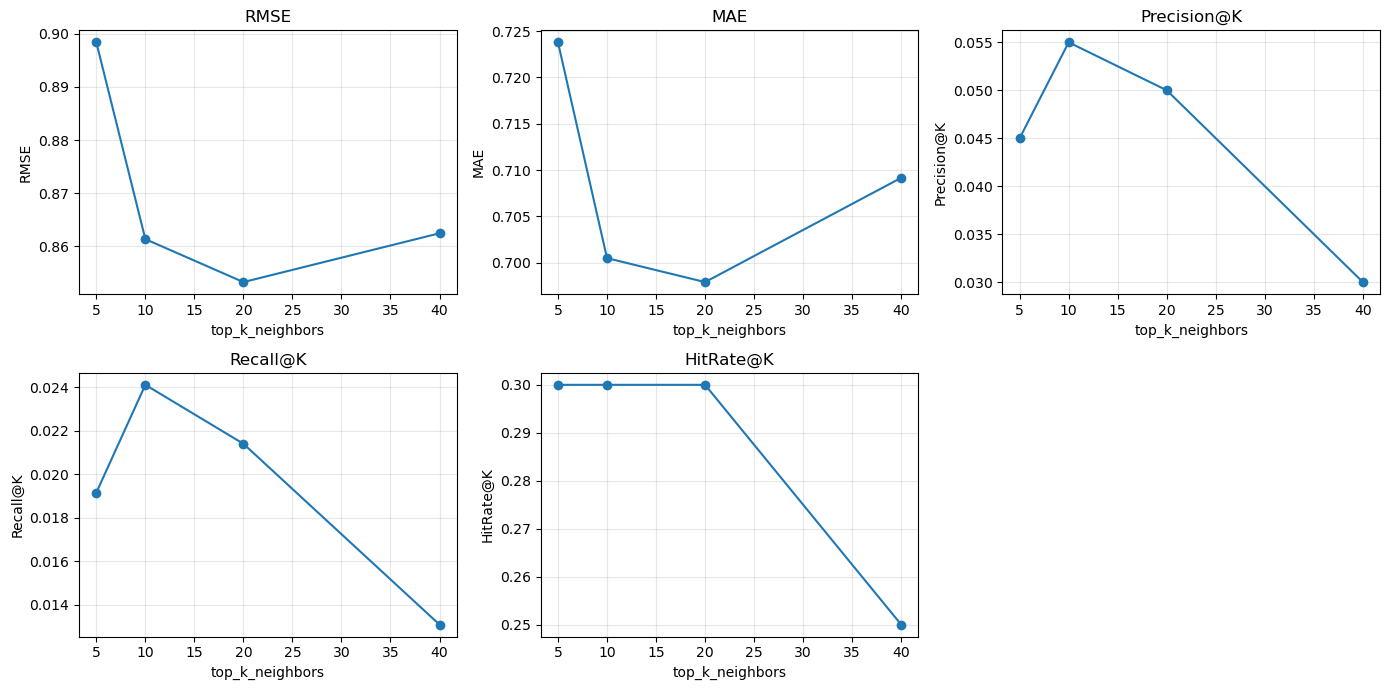

In [7]:
metrics = ['RMSE', 'MAE', 'Precision@K', 'Recall@K', 'HitRate@K']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, metric in zip(axes, metrics):
    ax.plot(sensitivity['top_k_neighbors'], sensitivity[metric], marker='o')
    ax.set_xlabel('top_k_neighbors')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(alpha=0.3)

for ax in axes[len(metrics):]:
    ax.axis('off')

fig.tight_layout()
plt.show()

## 7. 主模型全量评估与可视化

本节只评估主模型 `sklearn_centered_item_cf`，并覆盖测试集中全部可评估用户。模型之间的正式全量对比放在 `model_comparison.ipynb` 中。

In [8]:
full_eval_user_ids = [uid for uid in test_matrix.index if test_matrix.loc[uid].notna().any()]
full_test_ratings = int(test_matrix.loc[full_eval_user_ids].notna().sum().sum())

print('full evaluation users:', len(full_eval_user_ids))
print('full evaluation test ratings:', full_test_ratings)

full_evaluation_result = evaluate_algorithm(
    train_matrix=train_matrix,
    test_matrix=test_matrix,
    algorithm=MAIN_ALGORITHM,
    top_k_neighbors=20,
    top_n=10,
    relevance_threshold=4.0,
    user_ids=None,
)

display(full_evaluation_result)
display(full_evaluation_result.attrs['per_user_results'].head())

full evaluation users: 475
full evaluation test ratings: 14093


,algorithm,top_k_neighbors,top_n,n_users,n_test_ratings,n_users_with_relevant_items,RMSE,MAE,Weighted_RMSE,Weighted_MAE,Precision@K,Recall@K,HitRate@K,Precision@K_relevant_users,Recall@K_relevant_users,HitRate@K_relevant_users
0,sklearn_centered_item_cf,20,10,475,14093,469,0.798196,0.63823,0.802795,0.608938,0.064842,0.028754,0.317895,0.065672,0.029122,0.321962


,userId,n_test_ratings,n_predicted_test_ratings,n_relevant_items,n_hits,RMSE,MAE,SSE,SAE,Precision@K,Recall@K,HitRate@K
0,1,39,39,36,1,0.642749,0.540745,16.111936,21.089064,0.1,0.027778,1.0
1,4,30,30,17,0,1.563264,1.376421,73.313867,41.292628,0.0,0.000000,0.0
2,5,8,8,3,0,0.800059,0.712456,5.120755,5.699648,0.0,0.000000,0.0
3,6,37,37,23,1,0.871851,0.708744,28.124569,26.223531,0.1,0.043478,1.0
4,7,26,26,12,0,1.185704,0.874805,36.553232,22.744942,0.0,0.000000,0.0


## 8. 主模型全量 `top_k` 敏感性分析

继续在全量用户上测试 `top_k = 5, 10, 20, 40`，观察主模型在误差指标和 Top-N 命中指标上的变化。

In [9]:
full_sensitivity = sensitivity_analysis(
    matrix,
    top_k_values=(5, 10, 20, 40),
    test_size=0.2,
    random_state=42,
    top_n=10,
    relevance_threshold=4.0,
    user_ids=None,
    algorithms=(MAIN_ALGORITHM,),
)

display(full_sensitivity)

,algorithm,top_k_neighbors,top_n,n_users,n_test_ratings,n_users_with_relevant_items,RMSE,MAE,Weighted_RMSE,Weighted_MAE,Precision@K,Recall@K,HitRate@K,Precision@K_relevant_users,Recall@K_relevant_users,HitRate@K_relevant_users
0,sklearn_centered_item_cf,5,10,475,14093,469,0.833013,0.660409,0.845300,0.638652,0.061895,0.035708,0.355789,0.062687,0.036165,0.360341
1,sklearn_centered_item_cf,10,10,475,14093,469,0.806611,0.642302,0.813188,0.616095,0.065474,0.034578,0.353684,0.066311,0.035021,0.358209
2,sklearn_centered_item_cf,20,10,475,14093,469,0.798196,0.638230,0.802795,0.608938,0.064842,0.028754,0.317895,0.065672,0.029122,0.321962
3,sklearn_centered_item_cf,40,10,475,14093,469,0.799682,0.641716,0.802078,0.609957,0.062947,0.030439,0.315789,0.063753,0.030828,0.319829


## 9. 主模型全量评估结果可视化

下面把主模型的全量敏感性分析结果画成折线图，用于观察不同邻居数量下的指标变化。

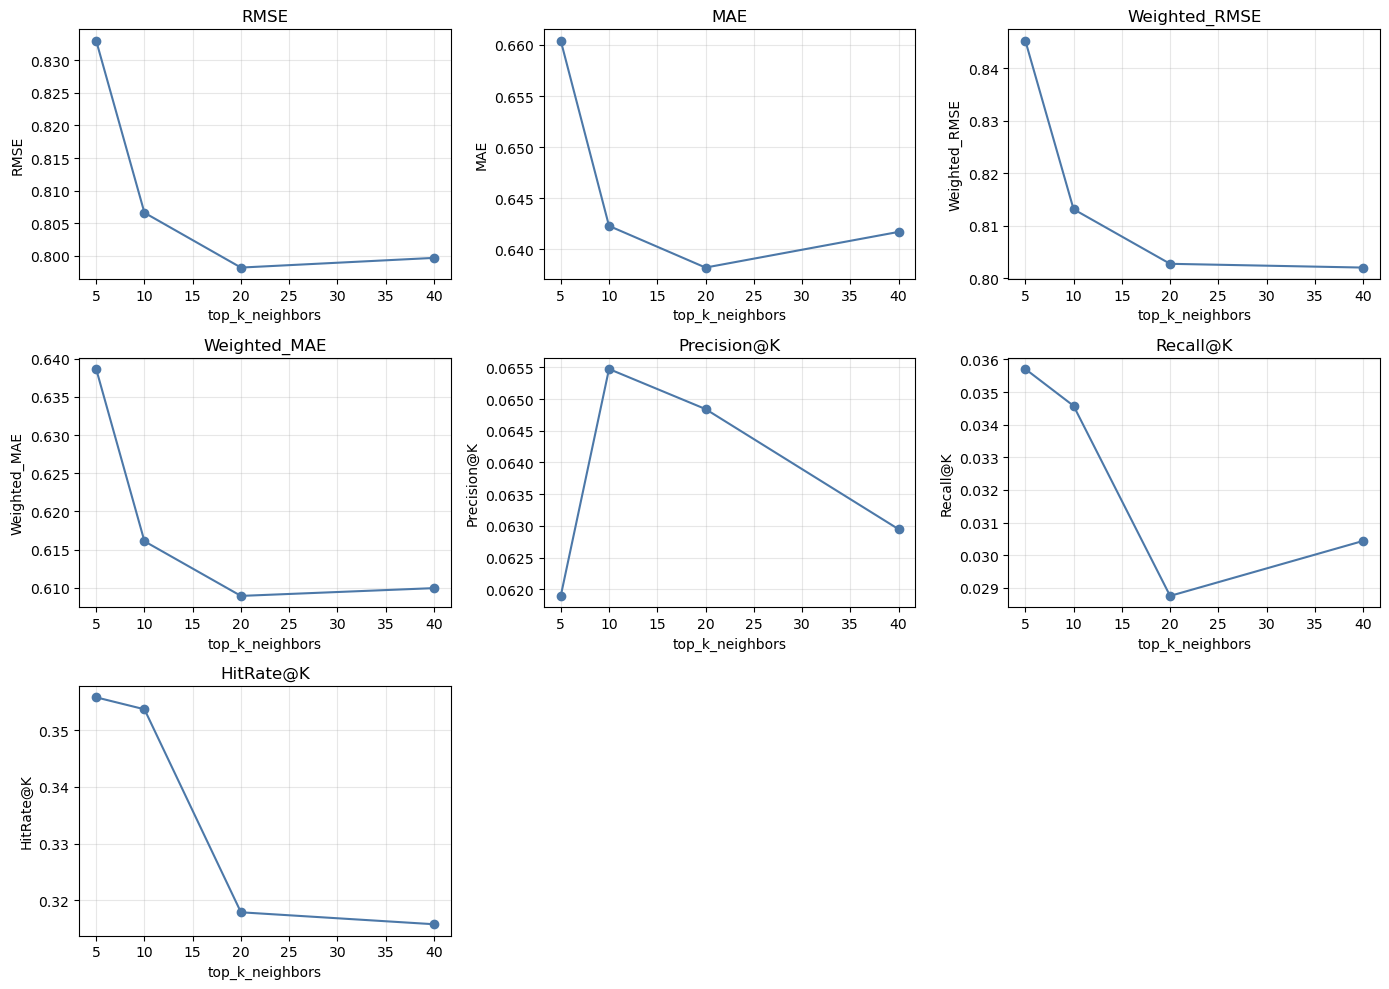

In [10]:
metrics = ['RMSE', 'MAE', 'Weighted_RMSE', 'Weighted_MAE', 'Precision@K', 'Recall@K', 'HitRate@K']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for ax, metric in zip(axes, metrics):
    ax.plot(full_sensitivity['top_k_neighbors'], full_sensitivity[metric], marker='o', color='#4C78A8')
    ax.set_xlabel('top_k_neighbors')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(alpha=0.3)

for ax in axes[len(metrics):]:
    ax.axis('off')

fig.tight_layout()
plt.show()

## 10. 结论记录

- 主模型为 `sklearn_centered_item_cf`，评估逻辑统一由 `src/evaluation.py` 提供，notebook 只负责展示和可视化。
- 第 4-6 节保留 20 用户快速演示，用于说明评估流程和检查图表生成，不作为最终实验结论。
- 第 7-9 节使用全量用户评估主模型，覆盖 475 个可评估用户和 14093 条测试评分。
- 本 notebook 不再承担模型优劣对比任务；两个模型的全量对比、敏感性分析和正式实验结论见 `model_comparison.ipynb`。